#**Clustering with KMeans Dataset Mall_Customers.csv from Kaggle**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Load our Datset to Pandas DataFrame

In [2]:
df=pd.read_csv("Mall_Customers.csv")

#**EDA**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
df.shape

(200, 5)

##Delete CustomerID because don't hold andy segnificant Data
##because adding noise to distance calculation

In [5]:
df=df.drop('CustomerID',axis=1)

In [6]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


##Descriptive statistics Central Tendency

In [7]:
df.describe(include='all')

,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200,200.000000,200.000000,200.000000
unique,2,NaN,NaN,NaN
top,Female,NaN,NaN,NaN
freq,112,NaN,NaN,NaN
mean,NaN,38.850000,60.560000,50.200000
std,NaN,13.969007,26.264721,25.823522
min,NaN,18.000000,15.000000,1.000000
25%,NaN,28.750000,41.500000,34.750000
50%,NaN,36.000000,61.500000,50.000000
75%,NaN,49.000000,78.000000,73.000000


In [8]:
df.Gender.value_counts()

,count
Gender,
Female,112
Male,88


##Check if there is missing  Data in our Data computational or visual

In [9]:
df.isnull().sum()

,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


<Axes: >

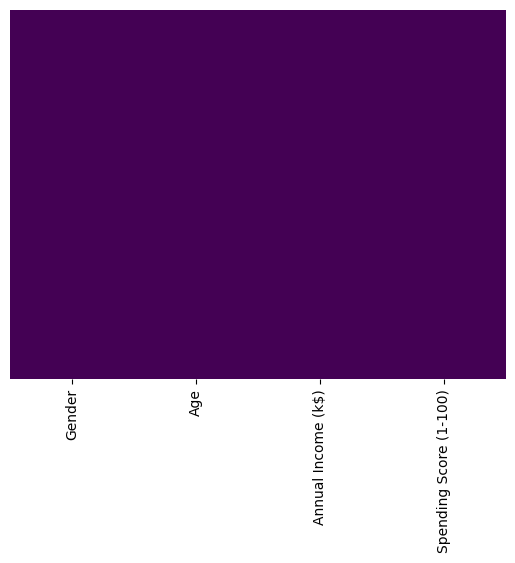

In [10]:
sns.heatmap(df.isnull(),cbar=False,yticklabels=False,cmap='viridis')

Form reading descriptives found that our data normally ditributed we can show that graphically by drawing hitogram for all for columns.

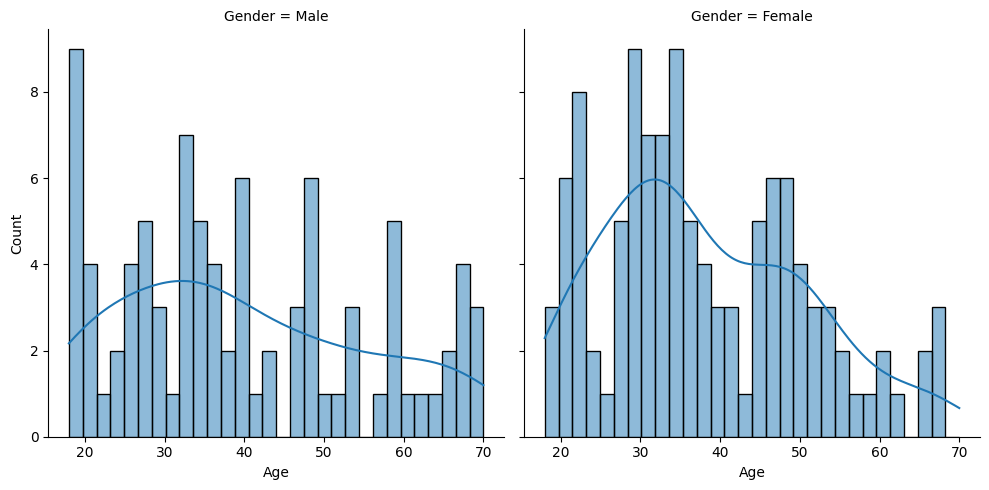

In [11]:
sns.displot(df,x='Age',kde=True,bins=30,col='Gender')

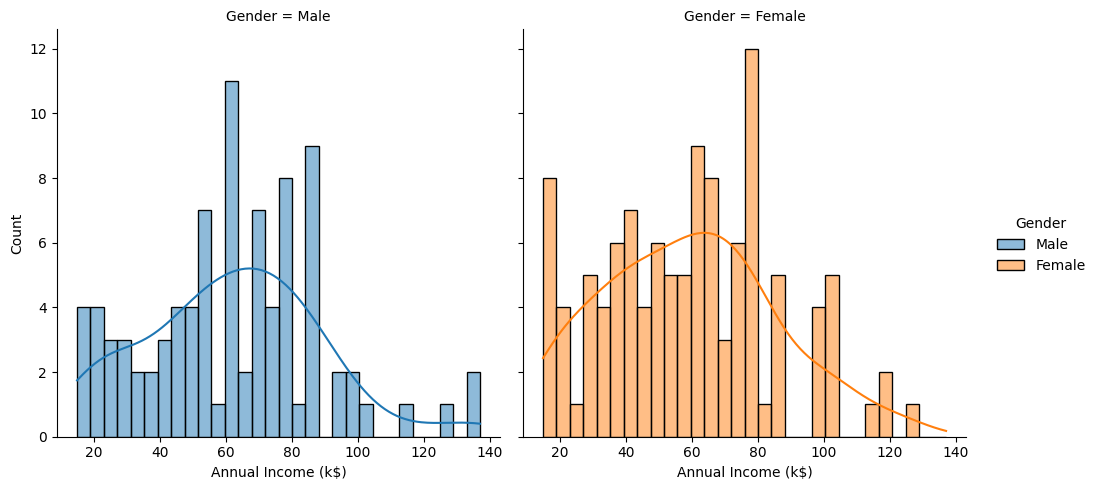

In [12]:
sns.displot(df,x='Annual Income (k$)',kde=True,bins=30,hue='Gender',col='Gender')

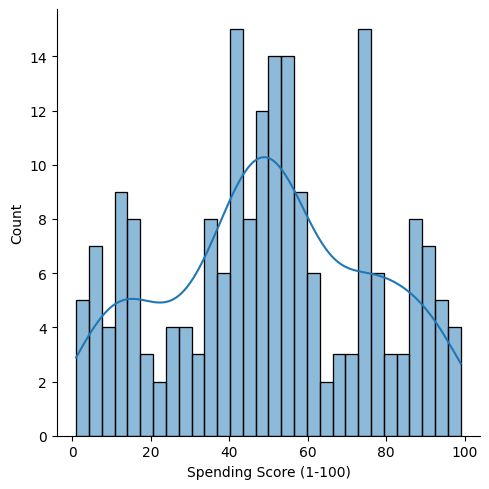

In [13]:
sns.displot(df,x='Spending Score (1-100)',kde=True,bins=30)

<Axes: >

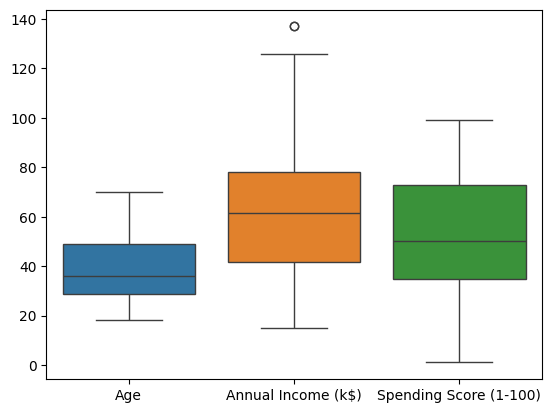

In [14]:
sns.boxplot(data=df)
#

Drawing the pairplot to see the relation between all features

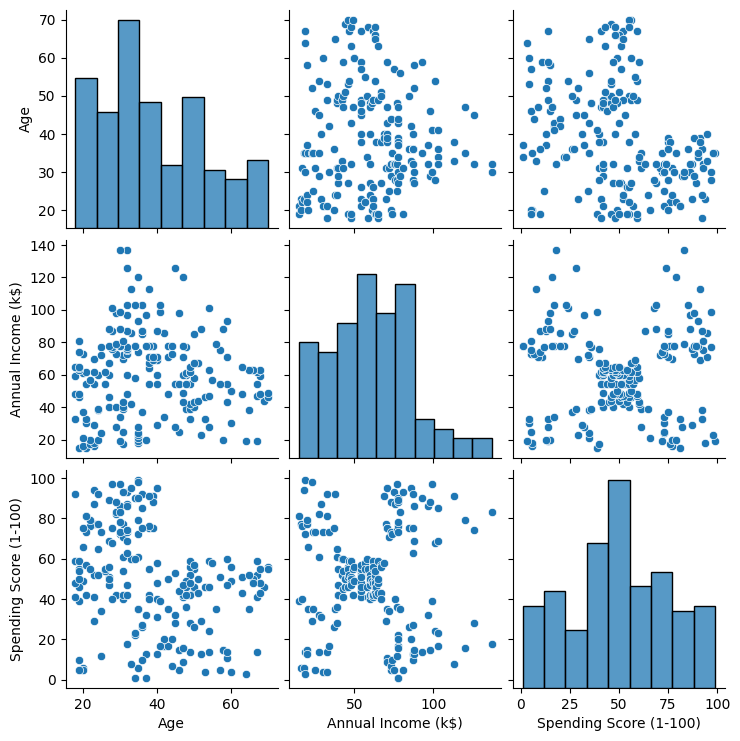

In [15]:
sns.pairplot(df)

**While the KMeans algorithm distace-based model it is very sensitive to scale of fetures we need to Scale our featrues and Convert the labled columns to prepare our Data for Modelling**

In [16]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [17]:
df.columns

Index(['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')

In [18]:
trns=ColumnTransformer(transformers=[('num',StandardScaler(),['Age', 'Annual Income (k$)', 'Spending Score (1-100)'])
,('cat',OneHotEncoder(drop='if_binary',handle_unknown='ignore'),['Gender'])])

In [19]:
df_scaled=trns.fit_transform(df)

In [20]:
type(df_scaled)

numpy.ndarray

#Using PCA to projection our Data to 2D for presentation

In [21]:
from sklearn.decomposition import PCA

In [22]:
pca=PCA(n_components=2,random_state=42)

In [23]:
df_scaled_pca=pca.fit_transform(df_scaled)

In [24]:
df_scaled_pca.shape

(200, 2)

Text(0, 0.5, 'Second Principal Component')

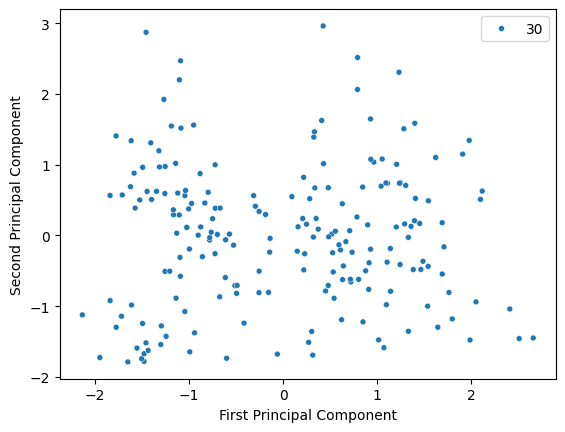

In [25]:

ax=sns.scatterplot(x=df_scaled_pca[:,0],y=df_scaled_pca[:,1],size=30)
ax.set_xlabel('First Principal Component')
ax.set_ylabel('Second Principal Component')


#Clustering KMeans

In [26]:
from sklearn.cluster import KMeans

Choose K using elbow method compute the SSE and choose k that apply least error

In [27]:
err=[]
for i in range(1,11):
  kmeans=KMeans(n_clusters=i,random_state=42)
  kmeans.fit(df_scaled)
  err.append(kmeans.inertia_)


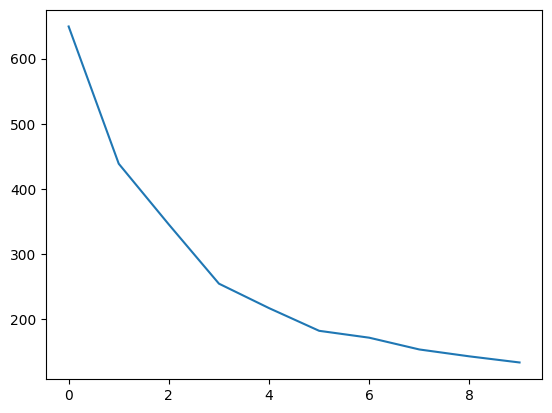

In [28]:
plt.plot(err)

<Axes: >

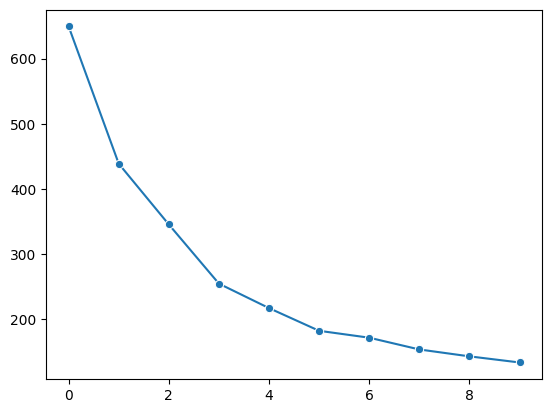

In [29]:
sns.lineplot(err,marker='o')
#

#**K==6**

In [30]:
km=KMeans(n_clusters=6,random_state=42,max_iter=1000)

In [31]:
km.fit(df_scaled)

KMeans(max_iter=1000, n_clusters=6, random_state=42)

# Show on 2_D with PCA

<Axes: >

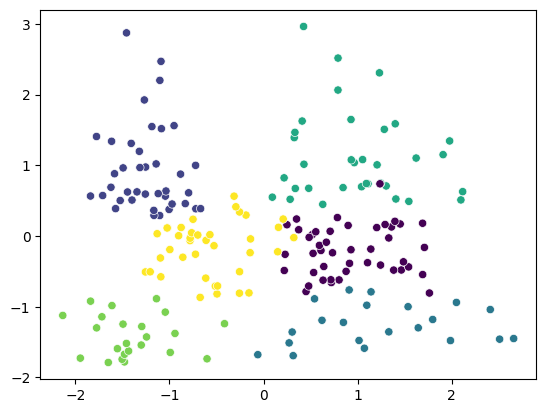

In [32]:
sns.scatterplot(x=df_scaled_pca[:,0],y=df_scaled_pca[:,1],c=km.labels_,cmap='viridis')

# Another metrics to find optimal k

In [33]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

results = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(df_scaled)
    sil = silhouette_score(df_scaled, labels)
    ch  = calinski_harabasz_score(df_scaled.toarray() if hasattr(df_scaled,'toarray') else df_scaled, labels)
    db  = davies_bouldin_score(df_scaled.toarray() if hasattr(df_scaled,'toarray') else df_scaled, labels)
    results.append((k, sil, ch, db))


for k, sil, ch, db in results:
   print(f"k={k}: silhouette={sil:.3f}  calinski-harabasz={ch:.0f}  davies-bouldin={db:.3f}")

k=2: silhouette=0.303  calinski-harabasz=95  davies-bouldin=1.361
k=3: silhouette=0.315  calinski-harabasz=87  davies-bouldin=1.152
k=4: silhouette=0.350  calinski-harabasz=101  davies-bouldin=1.065
k=5: silhouette=0.350  calinski-harabasz=97  davies-bouldin=1.025
k=6: silhouette=0.356  calinski-harabasz=100  davies-bouldin=1.005
k=7: silhouette=0.343  calinski-harabasz=92  davies-bouldin=1.117
k=8: silhouette=0.330  calinski-harabasz=91  davies-bouldin=1.089
k=9: silhouette=0.340  calinski-harabasz=88  davies-bouldin=1.008


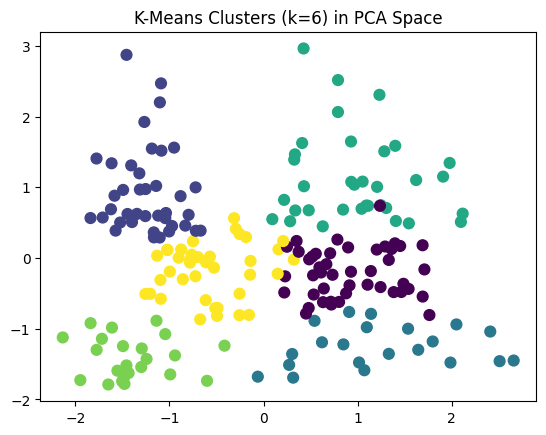

In [34]:
best_k = max(results, key=lambda t: t[1])[0]  # by silhouette
km_best = KMeans(n_clusters=best_k, n_init=50, random_state=42)
labels = km_best.fit_predict(df_scaled)

# Visualize on PCA space
plt.figure()
plt.scatter(df_scaled_pca[:,0], df_scaled_pca[:,1], c=labels, s=60, cmap='viridis')
plt.title(f'K-Means Clusters (k={best_k}) in PCA Space')
plt.show()

In [35]:
km_best.labels_

array([4, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4,
       2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0, 4, 2, 5,
       2, 4, 0, 5, 5, 5, 0, 5, 5, 0, 0, 0, 0, 0, 5, 0, 0, 5, 0, 0, 0, 5,
       0, 0, 5, 5, 0, 0, 0, 0, 0, 5, 0, 5, 5, 0, 0, 5, 0, 0, 5, 0, 0, 5,
       5, 0, 0, 5, 0, 5, 5, 5, 0, 5, 0, 5, 5, 0, 0, 5, 0, 5, 0, 0, 0, 0,
       0, 5, 5, 5, 5, 5, 0, 0, 0, 0, 5, 5, 5, 1, 5, 1, 3, 1, 3, 1, 3, 1,
       5, 1, 3, 1, 3, 1, 3, 1, 3, 1, 5, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

#**Agglomerative (Hierarchical) Clustering**

In [36]:
from sklearn.cluster import AgglomerativeClustering
agg = AgglomerativeClustering( linkage='ward')
labels_agg = agg.fit_predict(df_scaled)
print('Silhouette (Agglo):', silhouette_score(df_scaled, labels_agg))

Silhouette (Agglo): 0.2923040670626512


In [37]:
agg.labels_

array([0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1])

In [38]:
'''Number of Clusters hier in Agglo'''
len(np.unique(agg.labels_))
len(set(agg.labels_))

2

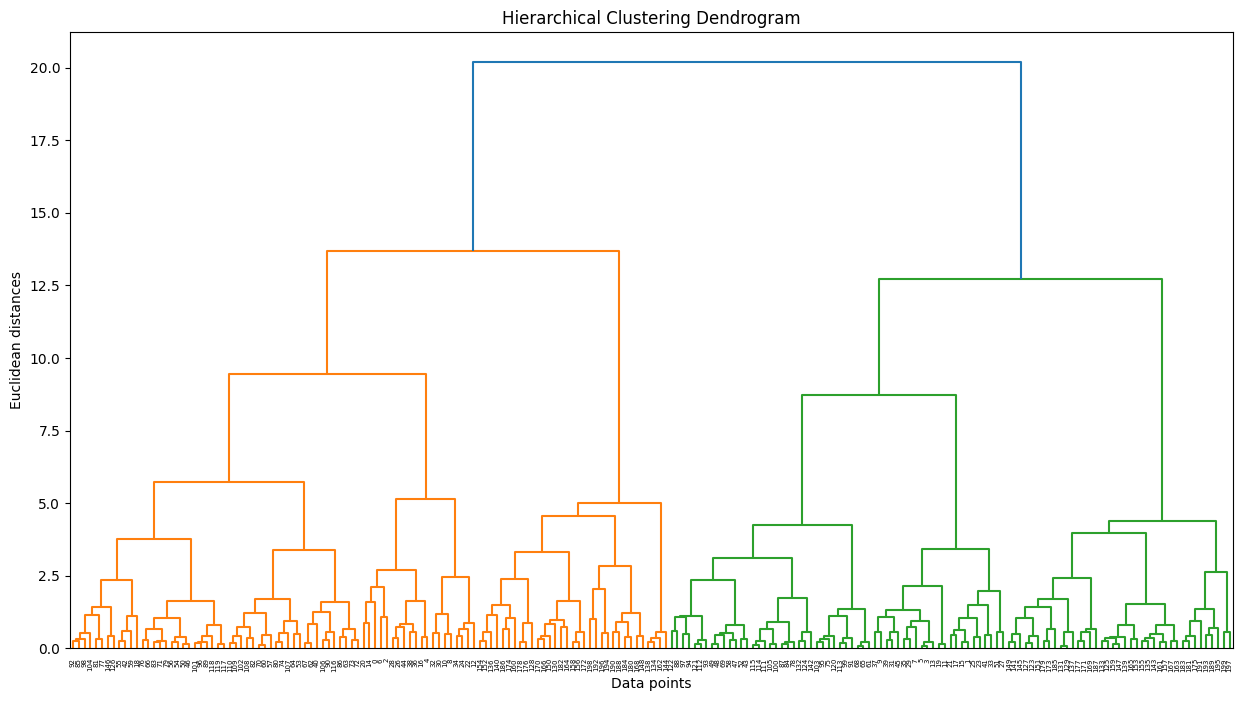

In [39]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Compute the linkage matrix
linked_data = linkage(df_scaled, method='ward')

# Plot the dendrogram
plt.figure(figsize=(15, 8))
dendrogram(linked_data,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Data points')
plt.ylabel('Euclidean distances')
plt.show()

# **DBSCAN**

In [40]:
from sklearn.cluster import DBSCAN

# eps needs tuning based on scaled features; start small
for eps in [0.3, 0.5, 0.7, 1.0]:
    db = DBSCAN(eps=eps, min_samples=5, n_jobs=-1)
    labels_db = db.fit_predict(df_scaled)
    n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
    if n_clusters > 1:
        sil = silhouette_score(df_scaled, labels_db)
        print(f"DBSCAN eps={eps}: clusters={n_clusters}, silhouette={sil:.3f}")
    else:
        print(f"DBSCAN eps={eps}: clusters={n_clusters} (too few for silhouette)")

DBSCAN eps=0.3: clusters=1 (too few for silhouette)
DBSCAN eps=0.5: clusters=9, silhouette=-0.011
DBSCAN eps=0.7: clusters=7, silhouette=-0.016
DBSCAN eps=1.0: clusters=2, silhouette=0.100


# **Cluster Profiling**

In [41]:
X_with_labels = df.copy()
X_with_labels['cluster'] = labels  # from chosen model

# Numeric summaries per cluster
for c in sorted(X_with_labels['cluster'].unique()):
    sub = X_with_labels[X_with_labels['cluster'] == c]
    print(f"\nCluster {c} (n={len(sub)})")
    print(sub[['Age','Annual Income (k$)','Spending Score (1-100)']].mean())
    print(sub['Gender'].value_counts(normalize=True))


Cluster 0 (n=45)
Age                       56.333333
Annual Income (k$)        54.266667
Spending Score (1-100)    49.066667
dtype: float64
Gender
Female    0.577778
Male      0.422222
Name: proportion, dtype: float64

Cluster 1 (n=39)
Age                       32.692308
Annual Income (k$)        86.538462
Spending Score (1-100)    82.128205
dtype: float64
Gender
Female    0.538462
Male      0.461538
Name: proportion, dtype: float64

Cluster 2 (n=21)
Age                       45.523810
Annual Income (k$)        26.285714
Spending Score (1-100)    19.380952
dtype: float64
Gender
Female    0.619048
Male      0.380952
Name: proportion, dtype: float64

Cluster 3 (n=34)
Age                       41.264706
Annual Income (k$)        88.500000
Spending Score (1-100)    16.764706
dtype: float64
Gender
Male      0.588235
Female    0.411765
Name: proportion, dtype: float64

Cluster 4 (n=23)
Age                       25.000000
Annual Income (k$)        25.260870
Spending Score (1-100)    77.60869

In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.03, random_state=42)
outlier_flag = iso.fit_predict(df_scaled)  # -1 is outlier

# Add the 'is_outlier' column to the DataFrame
df['is_outlier'] = (outlier_flag == -1)
print(df['is_outlier'].mean())  # fraction of flagged customers

0.03


In [ ]:
df.is_outlier.value_counts()

,count
is_outlier,
False,194
True,6


In [55]:
outlier_flag

array([ 1,  1, -1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1, -1, -1])